In [2]:
import pandas as pd
import external_func as ef
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url_1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
client_info_df = pd.read_csv(url_1, sep=",")
url_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
groups_df = pd.read_csv(url_2, sep=",")
url_pt_1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt"
df_1 = pd.read_csv(url_pt_1)
url_pt_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt"
df_2 = pd.read_csv(url_pt_2)

In [4]:
groups_df = ef.columns_formating(groups_df)

In [5]:
web_activity_df = pd.concat([df_1, df_2], axis=0, ignore_index=True)
web_activity_df["date_time"] = pd.to_datetime(web_activity_df["date_time"])
df_all = pd.merge(web_activity_df, groups_df, on='client_id', how='left')
df_all = df_all[df_all["variation"].notnull()]
df_all = df_all.sort_values(by=['visit_id', 'date_time']).reset_index(drop=True)
df_all = df_all[df_all.duplicated(subset=['visit_id', 'client_id', 'visitor_id', 'process_step', 'date_time']) == False]
df_all["process_step"] = df_all["process_step"].map({'start': 1, 'step_1': 2, 'step_2': 3, 'step_3': 4, 'confirm': 5})

df_all

,client_id,visitor_id,visit_id,process_step,date_time,variation
0,3561384,451664975_1722933822,100012776_37918976071_457913,5,2017-04-26 13:22:17,Test
1,3561384,451664975_1722933822,100012776_37918976071_457913,5,2017-04-26 13:23:09,Test
2,7338123,612065484_94198474375,100019538_17884295066_43909,1,2017-04-09 16:20:56,Test
3,7338123,612065484_94198474375,100019538_17884295066_43909,2,2017-04-09 16:21:12,Test
4,7338123,612065484_94198474375,100019538_17884295066_43909,3,2017-04-09 16:21:21,Test
...,...,...,...,...,...,...
321304,6627522,730634087_44272418812,999988789_76411676596_272843,1,2017-04-21 23:49:11,Test
321305,6627522,730634087_44272418812,999988789_76411676596_272843,2,2017-04-21 23:49:22,Test
321306,6627522,730634087_44272418812,999988789_76411676596_272843,3,2017-04-21 23:50:16,Test
321307,6627522,730634087_44272418812,999988789_76411676596_272843,2,2017-04-21 23:51:00,Test


In [6]:
journey_check = (df_all.groupby('visit_id')['process_step'].apply(list).reset_index(name='journey'))
journey_check.head(5)

,visit_id,journey
0,100012776_37918976071_457913,"[5, 5]"
1,100019538_17884295066_43909,"[1, 2, 3, 2, 2, 1, 1, 2, 3, 4, 5]"
2,100022086_87870757897_149620,"[1, 2, 3, 4, 5]"
3,100030127_47967100085_936361,[1]
4,100037962_47432393712_705583,"[1, 1, 2, 1]"


1. Preparing samples from test-population and control population

In [7]:
sample_visits = (df_all.sample(10, random_state=42))
sample_visits.sort_values(['client_id', 'visit_id', 'process_step', 'date_time'])

,client_id,visitor_id,visit_id,process_step,date_time,variation
245182,1046160,846717865_10895807542,786035907_59449635866_913235,2,2017-03-28 19:29:35,Test
126669,2118118,234669399_83082736894,456730531_27900231859_302752,4,2017-04-12 19:23:47,Test
38518,4491137,177305320_39636995044,207229991_42638620769_718189,1,2017-04-08 09:49:40,Control
76217,4845568,944644086_55901304515,314447540_39107136292_212031,5,2017-05-24 23:38:06,Test
274076,5059558,463059244_88850623782,866968119_44928451851_483661,4,2017-04-24 12:18:15,Test
60708,5324504,379649656_35539499950,270281453_43344072515_378157,1,2017-04-11 11:39:41,Test
155082,5713362,681222384_28752435501,535863705_15190186161_59866,5,2017-03-29 13:09:53,Control
125608,5842948,56272988_75581321852,453600283_35705990454_117319,3,2017-04-07 10:07:06,Control
35032,6413572,54776789_35506169402,197718307_76166540483_919437,2,2017-03-31 14:15:34,Test
12012,7017598,37231391_41431395013,132693738_60205262529_903376,1,2017-03-29 16:37:17,Control


**Conclusion**
The data from random sample give us the information about random destributio of client's web activities. We've got random data in all columns

2. Data preparation for KPI calculations

In [8]:
confirmed_path = [1,2,3,4,5]
journey_check['ideal_order_and_completed'] = journey_check['journey'].apply(lambda x: x == confirmed_path)

journey_check['ideal_order_and_completed'].value_counts()


ideal_order_and_completed
False    49381
True     19824
Name: count, dtype: int64

**Conclusion**
We have 19824 of completed cases and 49381 uncompleted

In [9]:
df_all = df_all.sort_values(['client_id', 'date_time'])
df_all['time_to_next'] = df_all.groupby('client_id')['date_time'].diff().dt.total_seconds()
df_all['is_backward'] = df_all['process_step'] < df_all.groupby('client_id')['process_step'].shift(1)


In [10]:
client_journey = df_all.groupby('client_id').agg(journey=('process_step', list), 
        session_sec=('time_to_next', 'sum'),
        date_time_start=('date_time', 'min'),
        date_time_stop=('date_time', 'max'),
        last_step=('process_step', 'last'),
        has_backward_nav=('is_backward', 'any'),
        variation=('variation', 'first'),).reset_index()

In [11]:
client_journey['is_ideal'] = client_journey['journey'].apply(lambda x: x == [1,2,3,4,5])
client_journey.groupby('variation')['has_backward_nav'].mean()

variation
Control    0.343320
Test       0.378004
Name: has_backward_nav, dtype: float64

In [12]:
client_journey

,client_id,journey,session_sec,date_time_start,date_time_stop,last_step,has_backward_nav,variation,is_ideal
0,555,"[1, 2, 3, 4, 5]",158.0,2017-04-15 12:57:56,2017-04-15 13:00:34,5,False,Test,True
1,647,"[1, 2, 3, 4, 5]",377.0,2017-04-12 15:41:28,2017-04-12 15:47:45,5,False,Test,True
2,934,"[1, 1, 1, 1]",142.0,2017-04-18 02:36:30,2017-04-18 02:38:52,1,False,Test,False
3,1028,"[1, 2, 2, 3, 4, 2, 2, 3, 2]",538.0,2017-04-08 18:51:28,2017-04-08 19:00:26,2,True,Control,False
4,1104,"[1, 1]",744135.0,2017-06-12 07:49:18,2017-06-20 22:31:33,1,False,Control,False
...,...,...,...,...,...,...,...,...,...
50495,9999150,"[1, 2, 1]",18.0,2017-05-29 16:55:12,2017-05-29 16:55:30,1,True,Test,False
50496,9999400,"[1, 2, 3, 4, 5]",119.0,2017-04-20 05:21:28,2017-04-20 05:23:27,5,False,Test,True
50497,9999626,"[1, 2]",8.0,2017-05-14 09:07:51,2017-05-14 09:07:59,2,False,Test,False
50498,9999729,"[1, 2, 1, 2, 3, 1, 1, 2, 3, 4, 5]",2860131.0,2017-04-05 13:40:49,2017-05-08 16:09:40,5,True,Test,False


2. Preparation web activity data for test group

In [13]:
test_clients = client_journey[(client_journey["variation"] == "Test")&(client_journey["is_ideal"] == False)&(client_journey["last_step"] == 5)]
error_rate_clients = client_journey[(client_journey["variation"] == "Test")&(client_journey["last_step"] == 5)]
test_clients.head(3)

,client_id,journey,session_sec,date_time_start,date_time_stop,last_step,has_backward_nav,variation,is_ideal
8,1336,"[1, 2, 3, 4, 5, 5, 5]",8268.0,2017-05-08 06:05:12,2017-05-08 08:23:00,5,False,Test,False
11,1516,"[1, 2, 3, 2, 3, 1, 1, 1, 1, 3, 2, 1, 2, 3, 4, 5]",110207.0,2017-04-05 15:53:31,2017-04-06 22:30:18,5,True,Test,False
12,1643,"[1, 1, 2, 1, 1, 1, 2, 3, 4, 5]",4812895.0,2017-04-15 15:06:00,2017-06-10 08:00:55,5,True,Test,False


In [56]:
backward_cases = test_clients[(test_clients["has_backward_nav"] == True)]["journey"]
forward_cases = test_clients[(test_clients["has_backward_nav"] == False)]["journey"]
proportion_f = test_clients["has_backward_nav"].mean() * 100

In [57]:
print("Amount of backward cases: ", backward_cases.value_counts().sum())
print("Amount of forward cases: ", forward_cases.value_counts().sum())
print("Proportin of forward cases: ", proportion_f.round(2))
print("Amount of journeys in test group: ", test_clients.shape[0])

Amount of backward cases:  5671
Amount of forward cases:  4211
Proportin of forward cases:  57.39
Amount of journeys in test group:  9882


**Conclusion**

- The amount of backward client journeys is 5671, the amount of forward client journeys is 4211.
- Proportin of forward cases:  57.39%

Based on your data clients encountered with errors and had to come back or restart the process

## Funnel Conversion. Test Group

In [16]:
back_cases = test_clients[(test_clients["has_backward_nav"] == True)]
forward_cases = test_clients[(test_clients["has_backward_nav"] == False)]

In [17]:
test_funnel_1_2b = back_cases["journey"].apply(lambda x: {1, 2}.issubset(x)).sum()
test_funnel_2_3b = back_cases["journey"].apply(lambda x: {2, 3}.issubset(x)).sum()
test_funnel_3_4b = back_cases["journey"].apply(lambda x: {3, 4}.issubset(x)).sum()
test_funnel_4_5b = back_cases["journey"].apply(lambda x: {4, 5}.issubset(x)).sum()

display("Amount of clients with Start → Step 1: " + str(test_funnel_1_2b))
display("Amount of clients with Step 1 → Step 2: " + str(test_funnel_2_3b))
display("Amount of clients with Step 2 → Step 3: " + str(test_funnel_3_4b))
display("Amount of clients with Step 3 → Confirm: " + str(test_funnel_4_5b))

'Amount of clients with Start → Step 1: 5657'

'Amount of clients with Step 1 → Step 2: 5639'

'Amount of clients with Step 2 → Step 3: 5642'

'Amount of clients with Step 3 → Confirm: 5652'

In [18]:
test_funnel_1_2f = forward_cases["journey"].apply(lambda x: {1, 2}.issubset(x)).sum()
test_funnel_2_3f = forward_cases["journey"].apply(lambda x: {2, 3}.issubset(x)).sum()
test_funnel_3_4f = forward_cases["journey"].apply(lambda x: {3, 4}.issubset(x)).sum()
test_funnel_4_5f = forward_cases["journey"].apply(lambda x: {4, 5}.issubset(x)).sum()

display("Amount of clients with Start → Step 1: " + str(test_funnel_1_2f))
display("Amount of clients with Step 1 → Step 2: " + str(test_funnel_2_3f))
display("Amount of clients with Step 2 → Step 3: " + str(test_funnel_3_4f))
display("Amount of clients with Step 3 → Confirm: " + str(test_funnel_4_5f))

'Amount of clients with Start → Step 1: 3934'

'Amount of clients with Step 1 → Step 2: 3967'

'Amount of clients with Step 2 → Step 3: 3963'

'Amount of clients with Step 3 → Confirm: 3993'

**Conclusions**

We can see that for 'backward' subset the amount of every step is above than in 'forward' subset

## Completion Time. Test Group


In [19]:
(back_cases["session_sec"].describe()).round(2)

count       5671.00
mean      789716.67
std      1502242.61
min           65.00
25%          445.00
50%         1858.00
75%       870150.50
max      8110545.00
Name: session_sec, dtype: float64

In [20]:
(forward_cases["session_sec"].describe()).round(2)

count       4211.00
mean      575442.71
std      1335273.76
min            0.00
25%          295.00
50%          843.00
75%       348198.50
max      7810368.00
Name: session_sec, dtype: float64

**Conclusions**

- For 'forward' subset we have sessions with 0 duration, but in 'backward' subset wwe have minumun 65 seconds
- All statustical values in 'back' subset are greater than in 'forward' subset, because such cases were time consuming to reach "confirmation" step

## Error Rate

In [38]:
client_journey["is_error"] = client_journey["journey"].apply(lambda x: x != confirmed_path)

In [39]:
client_journey.head(2)

,client_id,journey,session_sec,date_time_start,date_time_stop,last_step,has_backward_nav,variation,is_ideal,is_error
0,555,"[1, 2, 3, 4, 5]",158.0,2017-04-15 12:57:56,2017-04-15 13:00:34,5,False,Test,True,False
1,647,"[1, 2, 3, 4, 5]",377.0,2017-04-12 15:41:28,2017-04-12 15:47:45,5,False,Test,True,False


In [40]:
error_rate = client_journey.groupby('variation')['is_error'].mean() * 100
error_rate

variation
Control    68.727690
Test       69.326609
Name: is_error, dtype: float64

3. Preparation web activity data for control group

In [41]:
control_clients = client_journey[(client_journey["variation"] == "Control")&(client_journey["is_ideal"] == False)&(client_journey["last_step"] == 5)]
control_clients.head(3)

,client_id,journey,session_sec,date_time_start,date_time_stop,last_step,has_backward_nav,variation,is_ideal,is_error
7,1197,"[1, 2, 3, 4, 3, 4, 5]",95.0,2017-04-01 17:16:24,2017-04-01 17:17:59,5,True,Control,False,True
36,6985,"[1, 1, 2, 3, 4, 5]",626.0,2017-04-16 14:14:20,2017-04-16 14:24:46,5,False,Control,False,True
54,9767,"[1, 1, 2, 3, 4, 1, 2, 3, 4, 5]",1644332.0,2017-04-26 16:32:56,2017-05-15 17:18:28,5,True,Control,False,True


In [58]:
backward_cases_c = control_clients[(control_clients["has_backward_nav"] == True)]["journey"]
forward_cases_c = control_clients[(control_clients["has_backward_nav"] == False)]["journey"]
proportion_f_c = control_clients["has_backward_nav"].mean() * 100

In [59]:
print("Amount of backward cases in control group: ", backward_cases_c.value_counts().sum())
print("Amount of forward cases in control group: ", forward_cases_c.value_counts().sum())
print("Proportin of forward cases in control group: ", proportion_f_c.round(2))
print("Amount of journeys in test group in control group: ", control_clients.shape[0])

Amount of backward cases in control group:  3767
Amount of forward cases in control group:  2552
Proportin of forward cases in control group:  59.61
Amount of journeys in test group in control group:  6319


**Conclusion**

- The amount of backward client journeys is 3767, the amount of forward client journeys is 2552.
- Proportin of forward cases:  59.61%

Based on your data clients encountered with errors and had to come back or restart the process

## Funnel Conversion. Control group

In [44]:
back_cases_c = control_clients[(control_clients["has_backward_nav"] == True)]
forward_cases_c = control_clients[(control_clients["has_backward_nav"] == False)]

In [45]:
control_funnel_1_2b = back_cases_c["journey"].apply(lambda x: {1, 2}.issubset(x)).sum()
control_funnel_2_3b = back_cases_c["journey"].apply(lambda x: {2, 3}.issubset(x)).sum()
control_funnel_3_4b = back_cases_c["journey"].apply(lambda x: {3, 4}.issubset(x)).sum()
control_funnel_4_5b = back_cases_c["journey"].apply(lambda x: {4, 5}.issubset(x)).sum()

display("Amount of clients with Start → Step 1: " + str(control_funnel_1_2b))
display("Amount of clients with Step 1 → Step 2: " + str(control_funnel_2_3b))
display("Amount of clients with Step 2 → Step 3: " + str(control_funnel_3_4b))
display("Amount of clients with Step 3 → Confirm: " + str(control_funnel_4_5b))

'Amount of clients with Start → Step 1: 3744'

'Amount of clients with Step 1 → Step 2: 3738'

'Amount of clients with Step 2 → Step 3: 3741'

'Amount of clients with Step 3 → Confirm: 3745'

In [46]:
control_funnel_1_2f = forward_cases_c["journey"].apply(lambda x: {1, 2}.issubset(x)).sum()
control_funnel_2_3f = forward_cases_c["journey"].apply(lambda x: {2, 3}.issubset(x)).sum()
control_funnel_3_4f = forward_cases_c["journey"].apply(lambda x: {3, 4}.issubset(x)).sum()
control_funnel_4_5f = forward_cases_c["journey"].apply(lambda x: {4, 5}.issubset(x)).sum()

display("Amount of clients with Start → Step 1: " + str(control_funnel_1_2f))
display("Amount of clients with Step 1 → Step 2: " + str(control_funnel_2_3f))
display("Amount of clients with Step 2 → Step 3: " + str(control_funnel_3_4f))
display("Amount of clients with Step 3 → Confirm: " + str(control_funnel_4_5f))

'Amount of clients with Start → Step 1: 2436'

'Amount of clients with Step 1 → Step 2: 2444'

'Amount of clients with Step 2 → Step 3: 2424'

'Amount of clients with Step 3 → Confirm: 2470'

**Conclusions**

We can see that for 'backward' subset the amount of every step is above than in 'forward' subset

## Completion Time. Control Group

In [47]:
(back_cases_c["session_sec"].describe()).round(2)

count       3767.00
mean      999676.46
std      1734097.98
min           67.00
25%          376.50
50%         1191.00
75%      1219686.50
max      7802961.00
Name: session_sec, dtype: float64

In [48]:
(forward_cases_c["session_sec"].describe()).round(2)

count       2552.00
mean      802508.54
std      1551859.19
min            0.00
25%          311.00
50%          777.00
75%       775181.25
max      8373949.00
Name: session_sec, dtype: float64

**Conclusions**

For 'forward' subset we have sessions with 0 duration, but in 'backward' subset wwe have minumun 67 seconds.
All statustical values in 'back' subset are greater than in 'forward' subset, because such cases were time consuming to reach "confirmation" step

## 4. Validate KPIs

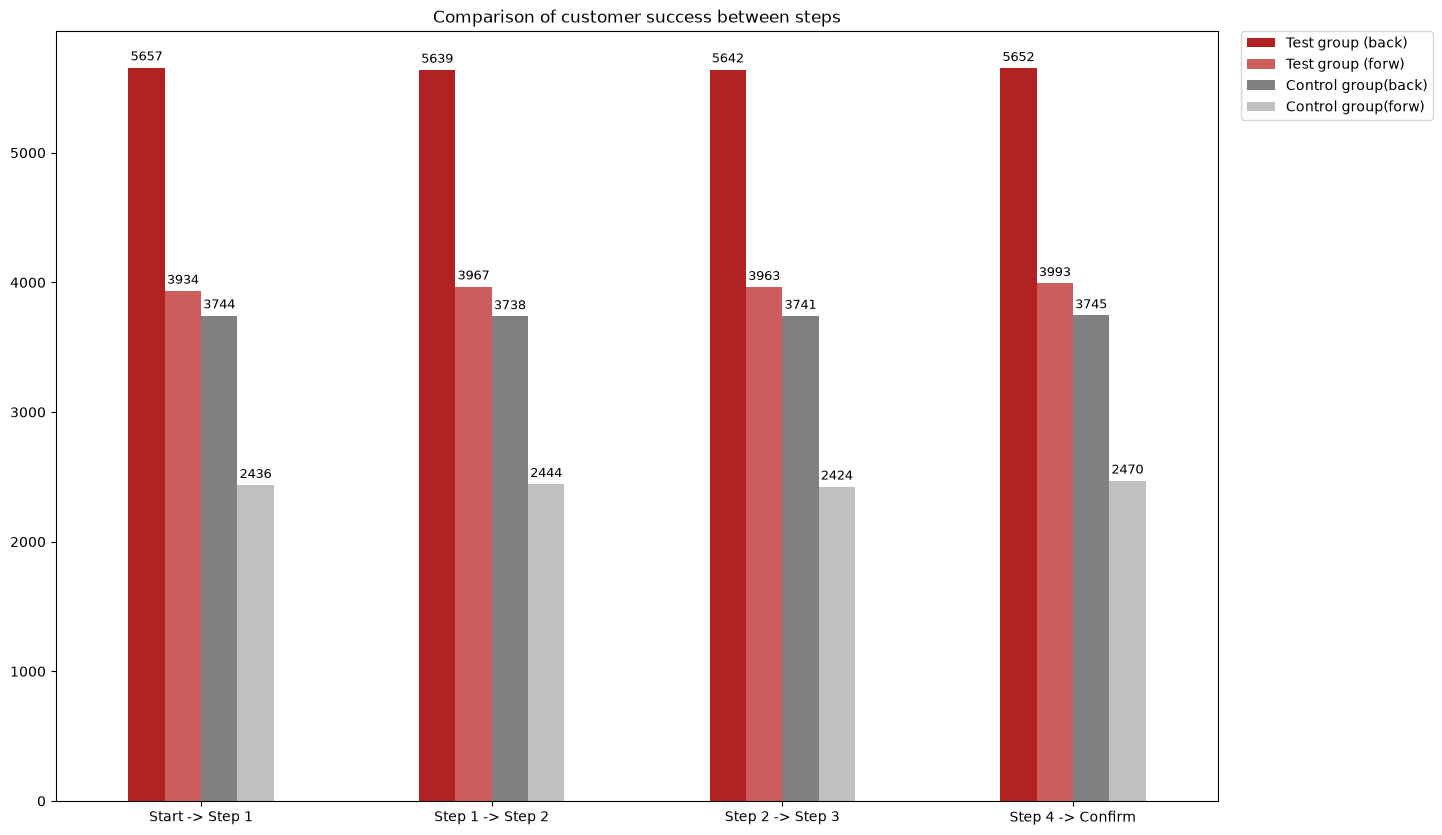

In [92]:
list_test_funnel_b = (test_funnel_1_2b, test_funnel_2_3b, test_funnel_3_4b, test_funnel_4_5b)
list_test_funnel_f = (test_funnel_1_2f, test_funnel_2_3f, test_funnel_3_4f, test_funnel_4_5f)
list_control_funnelb = (control_funnel_1_2b, control_funnel_2_3b, control_funnel_3_4b, control_funnel_4_5b)
list_control_funnelf = (control_funnel_1_2f, control_funnel_2_3f, control_funnel_3_4f, control_funnel_4_5f)
categ = ['Start -> Step 1', 'Step 1 -> Step 2', 'Step 2 -> Step 3', 'Step 4 -> Confirm']

colors = ["firebrick", "indianred", "gray", "silver"]

fig, ax = plt.subplots(figsize=(15, 10))
df_barplot = pd.DataFrame({'Test group (back)': list_test_funnel_b, 'Test group (forw)': list_test_funnel_f, 'Control group(back)': list_control_funnelb, 'Control group(forw)': list_control_funnelf}, index = categ)

df_barplot.plot.bar(rot=0, color=colors, legend=False, ax=ax)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.title('Comparison of customer success between steps')
plt.show()

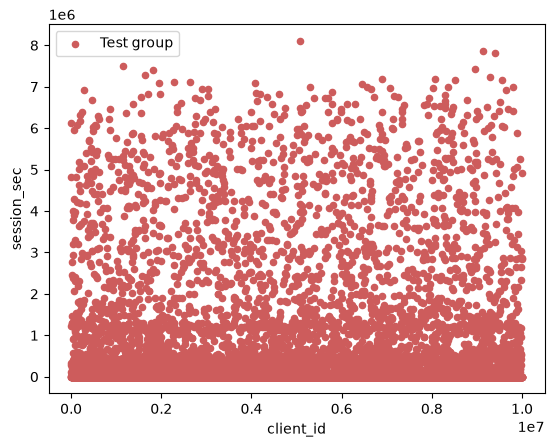

In [93]:
fig, ax = plt.subplots()
test_clients.plot.scatter(x='client_id', y='session_sec', color="indianred", label='Test group', ax=ax)
plt.show()

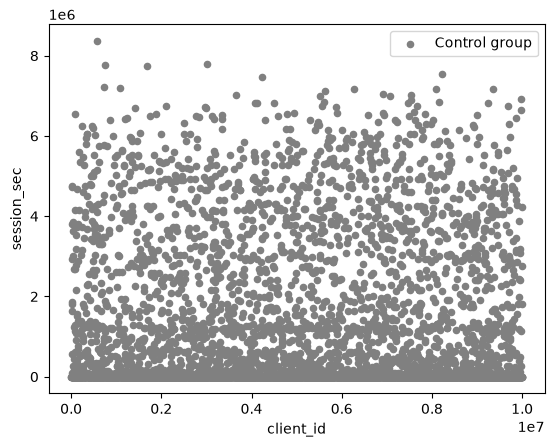

In [94]:
fig, ax = plt.subplots()

control_clients.plot.scatter(x='client_id', y='session_sec', color="gray", label='Control group', ax=ax)
plt.show()

## Statistical tests. Comparison of control and test group

In [52]:
# H0 - dataset for test group is equal to datasets for control group
# H1 - dataset for test group is not equal to datasets for control group 
 
alpha = 0.05

_, p_value = st.ttest_ind(control_clients["session_sec"], test_clients["session_sec"], equal_var=False)

In [53]:
p_value.round(2)

np.float64(0.0)

**Conclusion**
- Duration of sessions was increased in test group
- Amount backward steps in test group became greater than in control group
- Amount backward steps in test group became greater too
- Amount of completed journeys in test group decreased

All this result suggests us not to launch new feature for UI, because almost all our metrics are indicating decreasing usability

In [60]:
print("Amount of backward cases in control group:", backward_cases_c.value_counts().sum())
print("Amount of forward cases in control group:", forward_cases_c.value_counts().sum())
print("Proportin of forward cases in control group:", proportion_f_c.round(2))
print("Amount of completed journeys in test group :", control_clients.shape[0])

Amount of backward cases in control group: 3767
Amount of forward cases in control group: 2552
Proportin of forward cases in control group: 59.61
Amount of completed journeys in test group : 6319


In [61]:
print("Amount of backward cases in test group: ", backward_cases.value_counts().sum())
print("Amount of forward cases in test group: ", forward_cases.value_counts().sum())
print("Proportin of forward cases in test group: ", proportion_f.round(2))
print("Amount of completed journeys in test group: ", test_clients.shape[0])

Amount of backward cases in test group:  5671
Amount of forward cases in test group:  4211
Proportin of forward cases in test group:  57.39
Amount of completed journeys in test group:  9882
